In [1]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Загрузка данных
train = pd.read_csv('data/heart_train.csv')
test = pd.read_csv('data/heart_test.csv')

# Первичный осмотр
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (600000, 15)
Test shape: (400000, 14)


**Каждая запись содержит id пациента и 13 признаков:**

- Age (возраст);
- Sex (пол);
- Resting_blood_pressure (артериальное давление в состоянии покоя);
- Serum_cholestoral (уровень холестерина в крови mg/dl);
- Fasting_blood_sugar (анализ глюкозы в крови натощак (> 120 mg/dl));
- Maximum_heart_rate_achieved (максимальная частота сердечных сокращений);
- Exercise_induced_angina (стенокардия при нагрузке),
- Oldpeak (депрессия ST-сегмента);
- Slope (наклон пикового сегмента ST при физической нагрузке);
- Number_of_major_vessels (количество крупных сосудов (0-3), окрашенных с помощью флюороскопии);
- Resting_electrocardiographic_results (результаты электрокардиографических исследований в покое 0, 1, 2);
- Thal (3 = норма; 6 = фиксированный дефект; 7 = обратимый дефект);
- Chest_bin (боль в груди от 1 до 4).

In [2]:
train.head()

,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
0,0,49.207124,0,4.000000,162.996167,181.108682,0,0,148.227858,1,0.944547,2,0,3,1
1,1,53.628425,1,1.741596,130.233730,276.474630,0,2,152.917139,0,0.119070,2,0,3,0
2,2,49.591426,1,4.000000,146.999012,223.300517,1,2,102.352090,1,1.616747,2,2,7,1
3,3,58.991445,1,4.000000,112.369143,187.245501,0,0,158.164750,1,0.000000,1,1,7,1
4,4,51.053602,1,1.954609,138.032047,238.482868,0,0,172.540828,0,1.150464,1,1,3,0


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    600000 non-null  int64  
 1   age                                   600000 non-null  float64
 2   sex                                   600000 non-null  int64  
 3   chest                                 600000 non-null  float64
 4   resting_blood_pressure                600000 non-null  float64
 5   serum_cholestoral                     600000 non-null  float64
 6   fasting_blood_sugar                   600000 non-null  int64  
 7   resting_electrocardiographic_results  600000 non-null  int64  
 8   maximum_heart_rate_achieved           600000 non-null  float64
 9   exercise_induced_angina               600000 non-null  int64  
 10  oldpeak                               600000 non-null  float64
 11  

In [4]:
train.describe()

,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
count,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000
mean,299999.500000,54.426085,0.677447,3.170247,131.340485,249.592420,0.150757,1.020148,149.592069,0.333502,1.051391,1.596033,0.681303,4.711378,0.444185
std,173205.225094,9.086041,0.467454,0.949618,17.842450,51.699976,0.357812,0.994204,23.072593,0.471464,1.144288,0.629821,0.950669,1.934766,0.496875
min,0.000000,26.061695,0.000000,-0.538498,82.918527,98.326263,0.000000,0.000000,61.844168,0.000000,-0.806788,1.000000,0.000000,3.000000,0.000000
25%,149999.750000,48.078493,0.000000,3.000000,119.924094,216.475964,0.000000,0.000000,135.704237,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,299999.500000,55.133425,1.000000,3.000000,129.727941,244.233699,0.000000,2.000000,153.224828,0.000000,0.811101,2.000000,0.000000,3.000000,0.000000
75%,449999.250000,60.663775,1.000000,4.000000,139.915216,274.345453,0.000000,2.000000,165.165497,1.000000,1.674081,2.000000,1.000000,7.000000,1.000000
max,599999.000000,79.591647,1.000000,4.000000,209.673650,527.755764,1.000000,2.000000,208.735196,1.000000,6.803372,3.000000,3.000000,7.000000,1.000000


**Наблюдения:**

- 600 000 записей, 15 колонок
- Пропусков нет
- chest, age и некоторые другие признаки — дробные
- Целевая переменная class: 0 или 1

## Предобработка данных

In [5]:
# Удаляем ID (не несёт информации)
train = train.drop(columns=['ID'])

In [6]:
# Проверка невалидных значений
# chest должен быть от 1 до 4
print("Уникальные значения chest:", sorted(train['chest'].unique()[:10]))
# thal должен быть 3, 6 или 7
print("Уникальные значения thal:", sorted(train['thal'].unique()))
# slope должен быть 1, 2, 3
print("Уникальные значения slope:", sorted(train['slope'].unique()))
# number_of_major_vessels должен быть 0-3
print("Уникальные значения vessels:", sorted(train['number_of_major_vessels'].unique()))

Уникальные значения chest: [np.float64(1.6409650000000002), np.float64(1.727698), np.float64(1.741596), np.float64(1.954609), np.float64(1.995429), np.float64(2.127211), np.float64(2.1672689999999997), np.float64(2.223493), np.float64(3.0), np.float64(4.0)]
Уникальные значения thal: [np.int64(3), np.int64(6), np.int64(7)]
Уникальные значения slope: [np.int64(1), np.int64(2), np.int64(3)]
Уникальные значения vessels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [7]:
# Округляем chest до целых (1, 2, 3, 4)
train['chest'] = train['chest'].round().astype(int)
test['chest'] = test['chest'].round().astype(int)

# Фильтруем невалидные значения chest
train = train[train['chest'].isin([1, 2, 3, 4])]
test = test[test['chest'].isin([1, 2, 3, 4])]

print("Уникальные значения chest после округления:", sorted(train['chest'].unique()))
print("Размер train после фильтрации:", train.shape)

Уникальные значения chest после округления: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Размер train после фильтрации: (599092, 14)


In [8]:
# Удаляем ID из test тоже
test = test.drop(columns=['ID'])

In [9]:
# Категориальные переменные
cat_cols = ['sex', 'chest', 'fasting_blood_sugar', 
            'resting_electrocardiographic_results',
            'exercise_induced_angina', 'slope', 
            'number_of_major_vessels', 'thal']

train_encoded = pd.get_dummies(train, columns=cat_cols)
test_encoded = pd.get_dummies(test, columns=cat_cols)

In [10]:
# Выравниваем колонки train и test
test_encoded = test_encoded.reindex(columns=train_encoded.drop(columns=['class']).columns, fill_value=0)

print("\nРазмер train после кодирования:", train_encoded.shape)
print("Размер test после кодирования:", test_encoded.shape)
print("\nКолонки:", list(train_encoded.columns))


Размер train после кодирования: (599092, 29)
Размер test после кодирования: (399421, 28)

Колонки: ['age', 'resting_blood_pressure', 'serum_cholestoral', 'maximum_heart_rate_achieved', 'oldpeak', 'class', 'sex_0', 'sex_1', 'chest_1', 'chest_2', 'chest_3', 'chest_4', 'fasting_blood_sugar_0', 'fasting_blood_sugar_1', 'resting_electrocardiographic_results_0', 'resting_electrocardiographic_results_1', 'resting_electrocardiographic_results_2', 'exercise_induced_angina_0', 'exercise_induced_angina_1', 'slope_1', 'slope_2', 'slope_3', 'number_of_major_vessels_0', 'number_of_major_vessels_1', 'number_of_major_vessels_2', 'number_of_major_vessels_3', 'thal_3', 'thal_6', 'thal_7']


## Масштабирование и разделение данных

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Разделяем на признаки и целевую переменную
X = train_encoded.drop(columns=['class'])
y = train_encoded['class']

# Разделяем на train и validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Баланс классов в train:")
print(y_train.value_counts(normalize=True).round(3))

X_train: (479273, 28)
X_val: (119819, 28)
Баланс классов в train:
class
0    0.555
1    0.445
Name: proportion, dtype: float64


In [13]:
# Масштабирование числовых признаков
num_cols = ['age', 'resting_blood_pressure', 'serum_cholestoral', 
            'maximum_heart_rate_achieved', 'oldpeak']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
test_encoded[num_cols] = scaler.transform(test_encoded[num_cols])

print("\nМасштабирование выполнено!")
print("Пример X_train после масштабирования:")
print(X_train[num_cols].describe().round(3))


Масштабирование выполнено!
Пример X_train после масштабирования:
              age  resting_blood_pressure  serum_cholestoral  \
count  479273.000              479273.000         479273.000   
mean        0.000                  -0.000              0.000   
std         1.000                   1.000              1.000   
min        -3.119                  -2.714             -2.927   
25%        -0.700                  -0.640             -0.640   
50%         0.079                  -0.090             -0.104   
75%         0.686                   0.481              0.478   
max         2.769                   4.389              5.382   

       maximum_heart_rate_achieved     oldpeak  
count                   479273.000  479273.000  
mean                        -0.000       0.000  
std                          1.000       1.000  
min                         -3.744      -1.390  
25%                         -0.601      -0.920  
50%                          0.157      -0.208  
75%           

**Ключевые наблюдения**
- Баланс классов хороший (55/45) — не нужно делать балансировку
- Масштабирование выполнено корректно (mean ≈ 0, std = 1)

## Анализ данных (EDA)

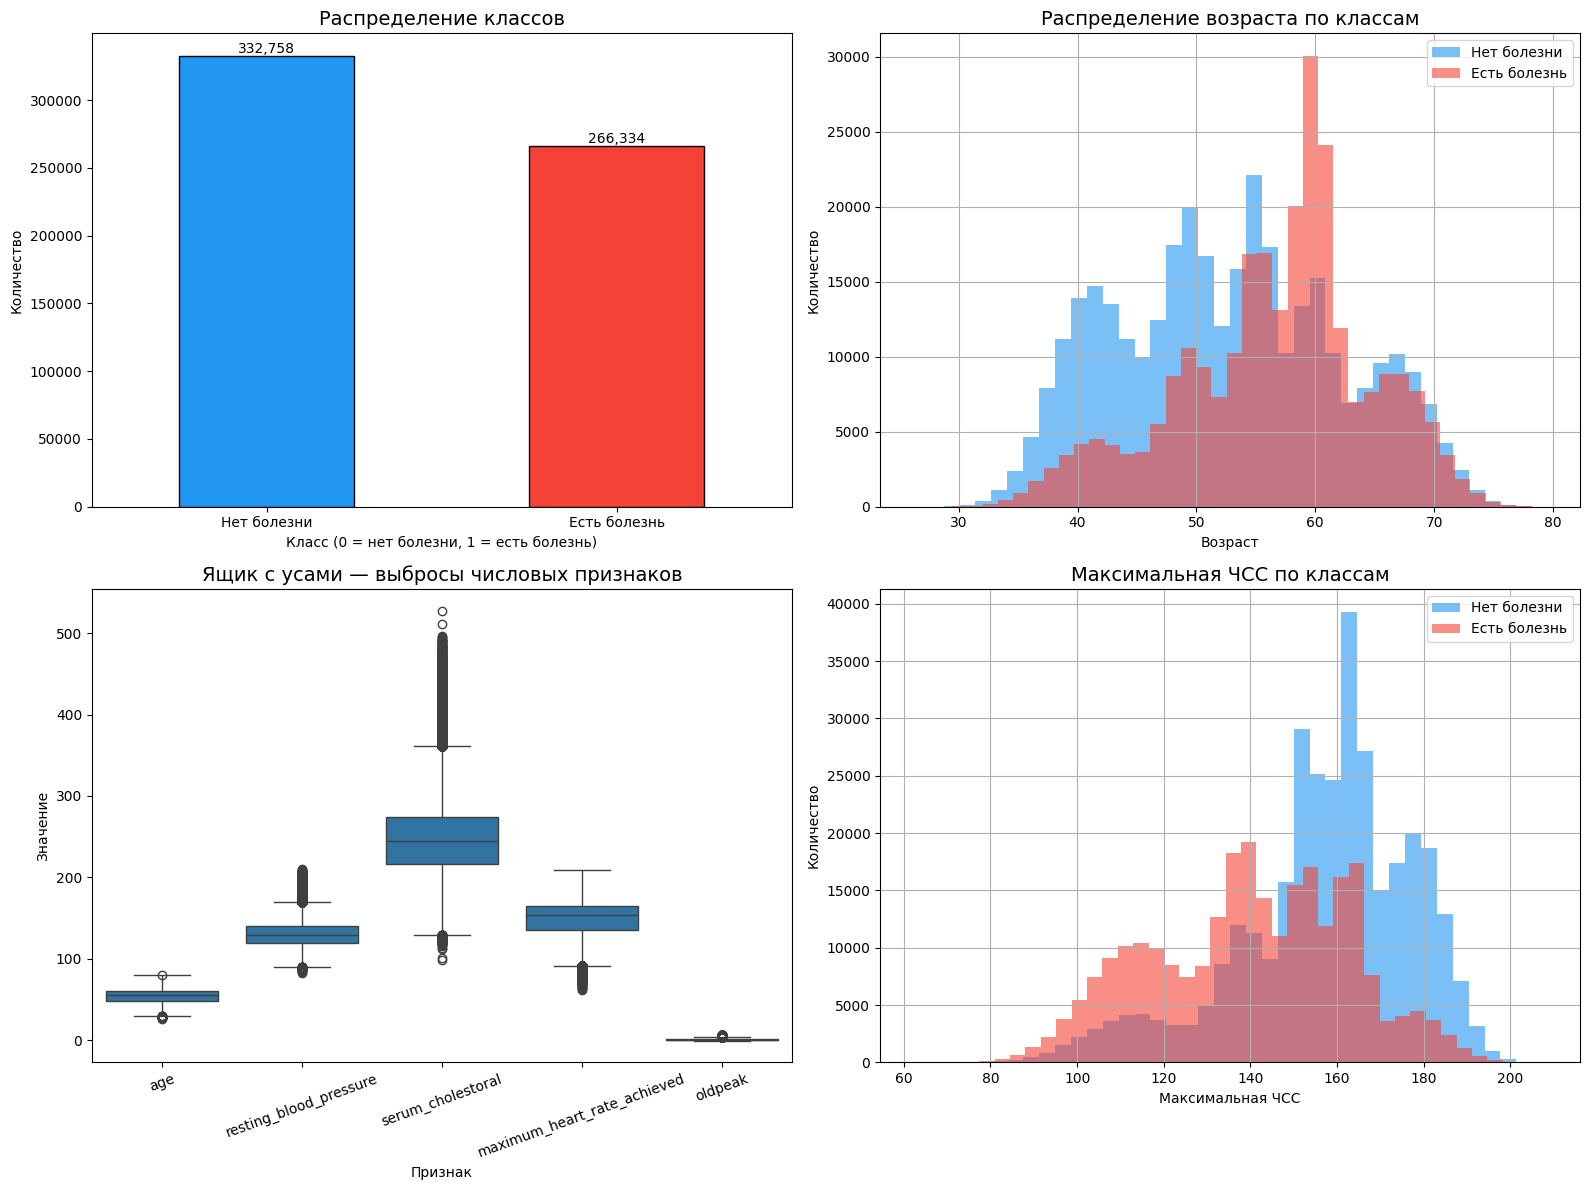

График сохранён!


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Распределение целевой переменной
ax1 = axes[0, 0]
y.value_counts().plot(kind='bar', ax=ax1, color=['#2196F3', '#F44336'], edgecolor='black')
ax1.set_title('Распределение классов', fontsize=14)
ax1.set_xlabel('Класс (0 = нет болезни, 1 = есть болезнь)')
ax1.set_ylabel('Количество')
ax1.set_xticklabels(['Нет болезни', 'Есть болезнь'], rotation=0)
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

# 2. Распределение возраста по классам
ax2 = axes[0, 1]
train[train['class']==0]['age'].hist(ax=ax2, alpha=0.6, color='#2196F3', 
                                      bins=40, label='Нет болезни')
train[train['class']==1]['age'].hist(ax=ax2, alpha=0.6, color='#F44336', 
                                      bins=40, label='Есть болезнь')
ax2.set_title('Распределение возраста по классам', fontsize=14)
ax2.set_xlabel('Возраст')
ax2.set_ylabel('Количество')
ax2.legend()

# 3. Боксплоты числовых признаков (выбросы)
ax3 = axes[1, 0]
num_data = train[num_cols].copy()
num_data_melted = num_data.melt(var_name='Признак', value_name='Значение')
sns.boxplot(data=num_data_melted, x='Признак', y='Значение', ax=ax3)
ax3.set_title('Ящик с усами — выбросы числовых признаков', fontsize=14)
ax3.tick_params(axis='x', rotation=20)

# 4. Распределение максимального ЧСС по классам
ax4 = axes[1, 1]
train[train['class']==0]['maximum_heart_rate_achieved'].hist(
    ax=ax4, alpha=0.6, color='#2196F3', bins=40, label='Нет болезни')
train[train['class']==1]['maximum_heart_rate_achieved'].hist(
    ax=ax4, alpha=0.6, color='#F44336', bins=40, label='Есть болезнь')
ax4.set_title('Максимальная ЧСС по классам', fontsize=14)
ax4.set_xlabel('Максимальная ЧСС')
ax4.set_ylabel('Количество')
ax4.legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён!")

**Ключевые наблюдения**
- Классы — почти сбалансированы (332k vs 266k), дополнительная балансировка не нужна
- Возраст — больные чаще старше 55 лет, здоровые моложе
- Выбросы — есть в serum_cholestoral (до 527) и resting_blood_pressure (до 209), но они медицински допустимы, удалять не будем
- ЧСС — у здоровых ЧСС выше (пик 160), у больных ниже (130) — хороший разделяющий признак

## Корреляционный анализ

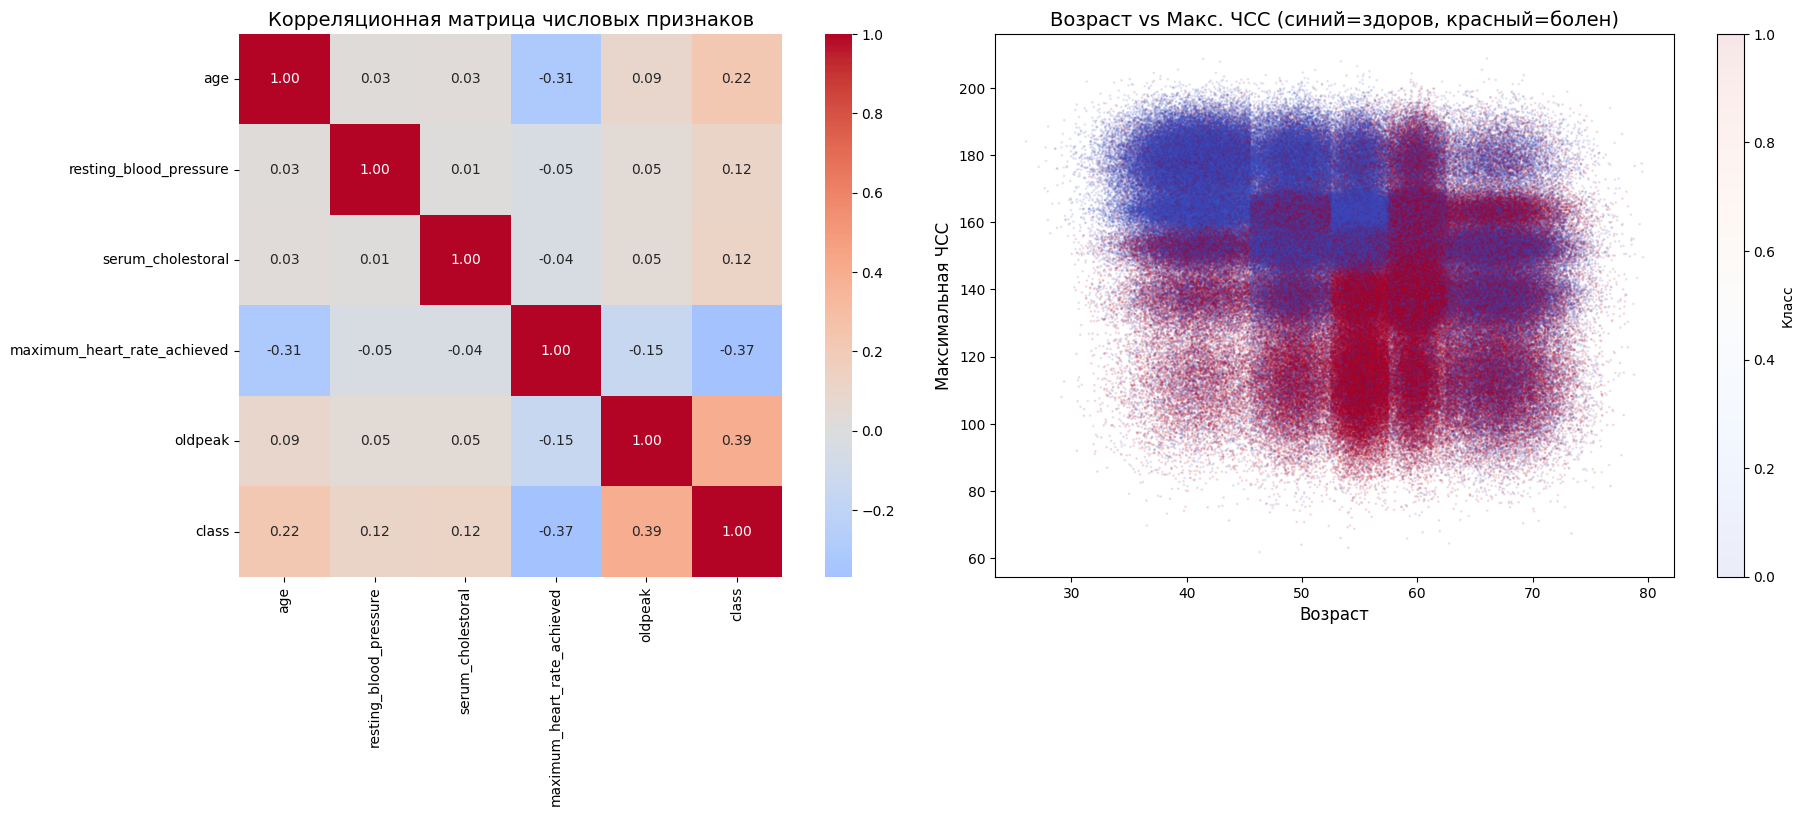

График сохранён!


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. Heatmap корреляционной матрицы (только числовые + class)
corr_cols = num_cols + ['class']
corr_matrix = train[corr_cols].corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            ax=axes[0],
            square=True)
axes[0].set_title('Корреляционная матрица числовых признаков', fontsize=14)

# 2. Scatter plot: возраст vs ЧСС с разбивкой по классу
scatter = axes[1].scatter(
    train['age'], 
    train['maximum_heart_rate_achieved'],
    c=train['class'],
    cmap='coolwarm',
    alpha=0.1,
    s=1
)
axes[1].set_xlabel('Возраст', fontsize=12)
axes[1].set_ylabel('Максимальная ЧСС', fontsize=12)
axes[1].set_title('Возраст vs Макс. ЧСС (синий=здоров, красный=болен)', fontsize=14)
plt.colorbar(scatter, ax=axes[1], label='Класс')

plt.tight_layout()
plt.savefig('correlation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён!")

**Ключевые наблюдения**

Корреляция с целевой переменной class:
- oldpeak +0.39 — сильнейший положительный признак (депрессия ST)
- maximum_heart_rate_achieved -0.37 — чем выше ЧСС, тем здоровее
- age +0.22 — старше = выше риск
- resting_blood_pressure и serum_cholestoral +0.12 — слабая связь

Scatter plot: чётко видно что при возрасте 50+ и низкой ЧСС (<140) концентрируются больные (красные точки)

## Обучение моделей

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, 
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
import time

results = {}

# 1. Обучение Logistic Regression
print("=" * 50)
print("Обучение Logistic Regression...")
start = time.time()

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_time = time.time() - start
lr_pred = lr.predict(X_val)
lr_proba = lr.predict_proba(X_val)[:, 1]

results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_val, lr_pred),
    'roc_auc': roc_auc_score(y_val, lr_proba),
    'time': lr_time
}

print(f"Время обучения: {lr_time:.1f}с")
print(f"Accuracy: {results['Logistic Regression']['accuracy']:.4f}")
print(f"ROC-AUC:  {results['Logistic Regression']['roc_auc']:.4f}")
print(classification_report(y_val, lr_pred))

Обучение Logistic Regression...
Время обучения: 0.5с
Accuracy: 0.8878
ROC-AUC:  0.9554
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     66552
           1       0.88      0.87      0.87     53267

    accuracy                           0.89    119819
   macro avg       0.89      0.89      0.89    119819
weighted avg       0.89      0.89      0.89    119819



In [21]:
# 2. Random Forest
print("=" * 50)
print("Обучение Random Forest...")
start = time.time()

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_time = time.time() - start
rf_pred = rf.predict(X_val)
rf_proba = rf.predict_proba(X_val)[:, 1]

results['Random Forest'] = {
    'accuracy': accuracy_score(y_val, rf_pred),
    'roc_auc': roc_auc_score(y_val, rf_proba),
    'time': rf_time
}

print(f"Время обучения: {rf_time:.1f}с")
print(f"Accuracy: {results['Random Forest']['accuracy']:.4f}")
print(f"ROC-AUC:  {results['Random Forest']['roc_auc']:.4f}")
print(classification_report(y_val, rf_pred))

Обучение Random Forest...
Время обучения: 52.1с
Accuracy: 0.8957
ROC-AUC:  0.9589
              precision    recall  f1-score   support

           0       0.90      0.91      0.91     66552
           1       0.89      0.88      0.88     53267

    accuracy                           0.90    119819
   macro avg       0.89      0.89      0.89    119819
weighted avg       0.90      0.90      0.90    119819



In [23]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# 3. Neural Network (PyTorch)
print("=" * 50)
print("Обучение Neural Network...")

# Подготовка данных
# Конвертируем все колонки в float
X_train = X_train.astype(float)
X_val = X_val.astype(float)
# Cоздаём тензоры
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.FloatTensor(y_train.values)
X_val_tensor = torch.FloatTensor(X_val.values)
y_val_tensor = torch.FloatTensor(y_val.values)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

# Архитектура сети
class HeartDiseaseNN(nn.Module):
    def __init__(self, input_dim):
        super(HeartDiseaseNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x).squeeze()

# Инициализация
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

model = HeartDiseaseNN(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

# Обучение
EPOCHS = 10
train_losses, val_losses, train_accs, val_accs = [], [], [], []

start = time.time()

for epoch in range(EPOCHS):
    # Train
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        predicted = (outputs > 0.5).float()
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
    
    train_loss = epoch_loss / len(train_loader)
    train_acc = correct / total
    
    # Validation
    model.eval()
    with torch.no_grad():
        X_val_dev = X_val_tensor.to(device)
        y_val_dev = y_val_tensor.to(device)
        val_outputs = model(X_val_dev)
        val_loss = criterion(val_outputs, y_val_dev).item()
        val_pred = (val_outputs > 0.5).float()
        val_acc = (val_pred == y_val_dev).sum().item() / len(y_val_dev)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    scheduler.step()
    
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

nn_time = time.time() - start
print(f"\nВремя обучения: {nn_time:.1f}с")

Обучение Neural Network...
Устройство: cpu
Epoch 1/10 | Train Loss: 0.2857 | Train Acc: 0.8854 | Val Loss: 0.2571 | Val Acc: 0.8936
Epoch 2/10 | Train Loss: 0.2593 | Train Acc: 0.8936 | Val Loss: 0.2528 | Val Acc: 0.8959
Epoch 3/10 | Train Loss: 0.2560 | Train Acc: 0.8951 | Val Loss: 0.2502 | Val Acc: 0.8966
Epoch 4/10 | Train Loss: 0.2537 | Train Acc: 0.8960 | Val Loss: 0.2492 | Val Acc: 0.8971
Epoch 5/10 | Train Loss: 0.2523 | Train Acc: 0.8965 | Val Loss: 0.2489 | Val Acc: 0.8973
Epoch 6/10 | Train Loss: 0.2518 | Train Acc: 0.8968 | Val Loss: 0.2482 | Val Acc: 0.8975
Epoch 7/10 | Train Loss: 0.2514 | Train Acc: 0.8972 | Val Loss: 0.2481 | Val Acc: 0.8974
Epoch 8/10 | Train Loss: 0.2507 | Train Acc: 0.8972 | Val Loss: 0.2476 | Val Acc: 0.8977
Epoch 9/10 | Train Loss: 0.2509 | Train Acc: 0.8974 | Val Loss: 0.2478 | Val Acc: 0.8974
Epoch 10/10 | Train Loss: 0.2499 | Train Acc: 0.8977 | Val Loss: 0.2472 | Val Acc: 0.8975

Время обучения: 22.0с


In [24]:
# Финальные метрики нейронной сети
model.eval()
with torch.no_grad():
    nn_proba = model(X_val_tensor.to(device)).cpu().numpy()
    nn_pred = (nn_proba > 0.5).astype(int)

results['Neural Network'] = {
    'accuracy': accuracy_score(y_val, nn_pred),
    'roc_auc': roc_auc_score(y_val, nn_proba),
    'time': nn_time
}

print(f"Accuracy: {results['Neural Network']['accuracy']:.4f}")
print(f"ROC-AUC:  {results['Neural Network']['roc_auc']:.4f}")
print(classification_report(y_val, nn_pred))

Accuracy: 0.8975
ROC-AUC:  0.9620
              precision    recall  f1-score   support

           0       0.90      0.91      0.91     66552
           1       0.89      0.88      0.88     53267

    accuracy                           0.90    119819
   macro avg       0.90      0.90      0.90    119819
weighted avg       0.90      0.90      0.90    119819



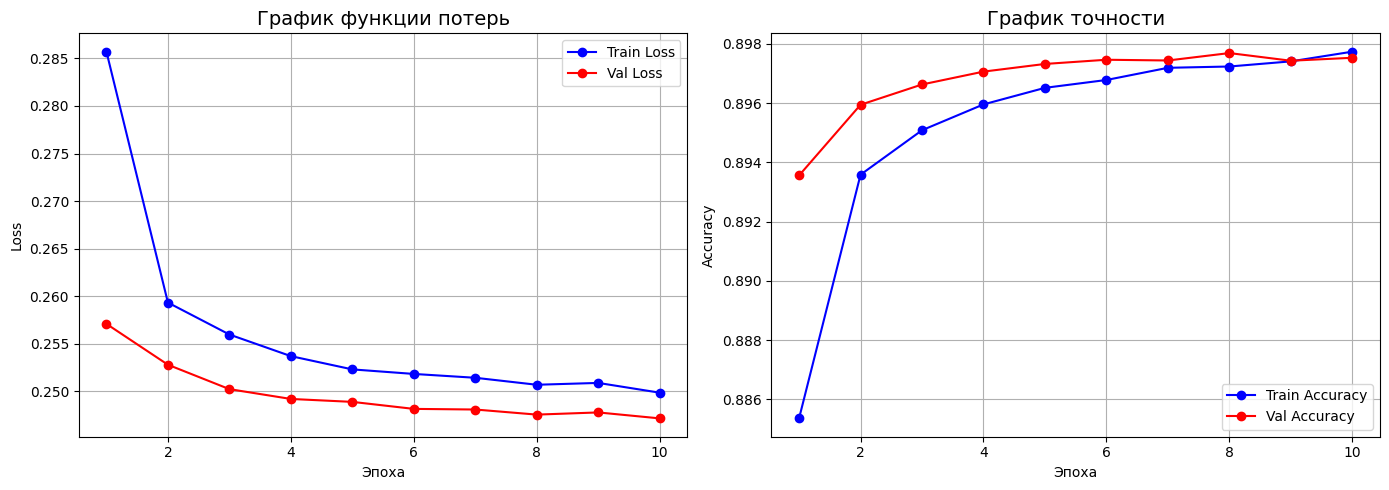

In [25]:
# Графики обучения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, EPOCHS+1), train_losses, 'b-o', label='Train Loss')
axes[0].plot(range(1, EPOCHS+1), val_losses, 'r-o', label='Val Loss')
axes[0].set_title('График функции потерь', fontsize=14)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(1, EPOCHS+1), train_accs, 'b-o', label='Train Accuracy')
axes[1].plot(range(1, EPOCHS+1), val_accs, 'r-o', label='Val Accuracy')
axes[1].set_title('График точности', fontsize=14)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('nn_training.png', dpi=150, bbox_inches='tight')
plt.show()

**Ключевые наблюдения по модели обучения:**
- Loss стабильно снижается, переобучения нет
- Accuracy растёт и выходит на плато 89.75%
- Train и Val кривые идут параллельно — признак здорового обучения

## Сравнение моделей


ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ
                     accuracy  roc_auc     time
Logistic Regression    0.8878   0.9554   0.4911
Random Forest          0.8957   0.9589  52.0866
Neural Network         0.8975   0.9620  22.0388


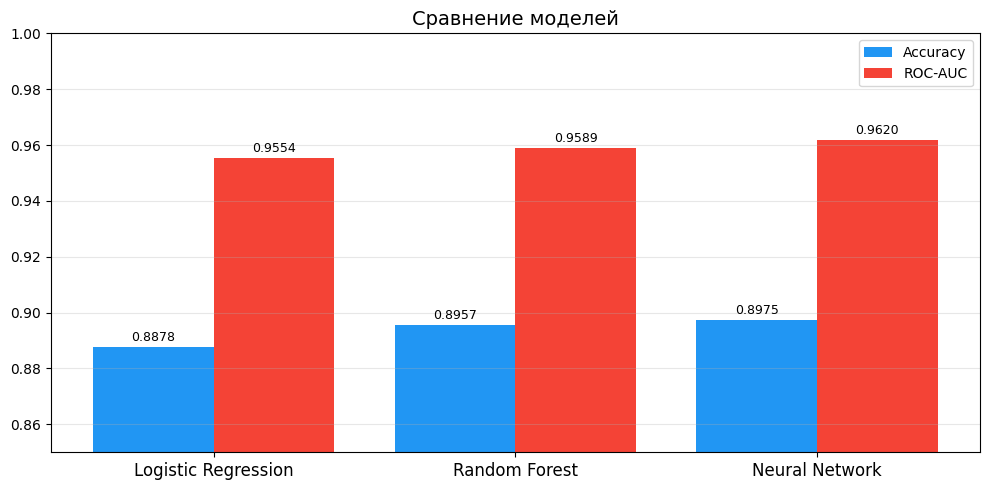

In [26]:
print("\n" + "=" * 50)
print("ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 50)
comparison = pd.DataFrame(results).T
comparison = comparison.round(4)
print(comparison)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(results))
bars1 = ax.bar([i - 0.2 for i in x], 
               [v['accuracy'] for v in results.values()], 
               0.4, label='Accuracy', color='#2196F3')
bars2 = ax.bar([i + 0.2 for i in x], 
               [v['roc_auc'] for v in results.values()], 
               0.4, label='ROC-AUC', color='#F44336')
ax.set_xticks(x)
ax.set_xticklabels(results.keys(), fontsize=12)
ax.set_ylim(0.85, 1.0)
ax.set_title('Сравнение моделей', fontsize=14)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Сохранение лучшей модели (Neural Network) и scaler

In [27]:
import pickle

# Сохраняем веса нейронной сети
torch.save(model.state_dict(), 'best_model.pth')

# Сохраняем scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Сохраняем список колонок (нужен для инференса)
feature_columns = list(X_train.columns)
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print("Сохранено:")
print("- best_model.pth (веса нейронной сети)")
print("- scaler.pkl (масштабировщик)")
print("- feature_columns.pkl (список признаков)")
print(f"\nВходная размерность модели: {len(feature_columns)}")

Сохранено:
- best_model.pth (веса нейронной сети)
- scaler.pkl (масштабировщик)
- feature_columns.pkl (список признаков)

Входная размерность модели: 28
